# Energy Consumption Prediction — Linear Regression
## Using the Energy Efficiency Dataset (UCI / ucimlrepo)

## About the Dataset

We use the **Energy Efficiency dataset** from the UCI Machine Learning Repository.  
It was created by Angeliki Tsanas and Argyris Xifara (2012) using a building energy simulation tool (Ecotect).

The dataset contains **768 building configurations**, each described by 8 architectural features.  
The two prediction targets are:
- **Y1 — Heating Load** (kWh/m²): energy needed to heat the building
- **Y2 — Cooling Load** (kWh/m²): energy needed to cool the building

**In this notebook we predict Heating Load (Y1).**

| Feature | Symbol | Description |
|---|---|---|
| Relative Compactness | X1 | Ratio of surface area to volume — compact buildings lose less heat |
| Surface Area | X2 | Total external surface area (m²) |
| Wall Area | X3 | Total wall area (m²) |
| Roof Area | X4 | Total roof area (m²) |
| Overall Height | X5 | Building height (m) |
| Orientation | X6 | 2=North, 3=East, 4=South, 5=West |
| Glazing Area | X7 | Proportion of floor area that is glazed (0–0.4) |
| Glazing Distribution | X8 | Where the glazing is placed (0–5) |

---

## Workflow
1. Install & load the dataset from `ucimlrepo` (built-in library method)
2. Explore & visualise
3. Train/test split + scaling
4. Simple Linear Regression baseline
5. Full multiple regression
6. Compare with Ridge Regression
7. Evaluation & feature importance
8. Predict on new buildings

## Step 1 — Install ucimlrepo & Load Dataset

`ucimlrepo` is the official Python package maintained by UCI to fetch their datasets programmatically — no manual download needed.

In [1]:
# Install the UCI ML repo package (not pre-installed in Colab)
!pip install ucimlrepo --quiet

from ucimlrepo import fetch_ucirepo

# Fetch Energy Efficiency dataset (id=242)
# This downloads directly from UCI — requires internet access
energy_ds = fetch_ucirepo(id=242)

X_raw = energy_ds.data.features          # pandas DataFrame
y_raw = energy_ds.data.targets           # DataFrame with Y1 (Heating) and Y2 (Cooling)

print("Dataset loaded successfully ✅")
print(f"Features shape : {X_raw.shape}")
print(f"Targets shape  : {y_raw.shape}")
print(f"\nFeature columns : {list(X_raw.columns)}")
print(f"Target  columns : {list(y_raw.columns)}")

Dataset loaded successfully ✅
Features shape : (768, 8)
Targets shape  : (768, 2)

Feature columns : ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
Target  columns : ['Y1', 'Y2']


## Step 2 — Build the Working DataFrame

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110

# Rename columns for clarity
feature_names = [
    "Compactness", "SurfaceArea", "WallArea",
    "RoofArea", "Height", "Orientation",
    "GlazingArea", "GlazingDistrib",
]

df = X_raw.copy()
df.columns = feature_names
df["HeatingLoad"] = y_raw.iloc[:, 0].values   # Y1 — our prediction target
df["CoolingLoad"]  = y_raw.iloc[:, 1].values  # Y2 — kept for reference

print(f"Shape: {df.shape}")
df.head(8)

Shape: (768, 10)


,Compactness,SurfaceArea,WallArea,RoofArea,Height,Orientation,GlazingArea,GlazingDistrib,HeatingLoad,CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
5,0.90,563.5,318.5,122.50,7.0,3,0.0,0,21.46,25.38
6,0.90,563.5,318.5,122.50,7.0,4,0.0,0,20.71,25.16
7,0.90,563.5,318.5,122.50,7.0,5,0.0,0,19.68,29.60


## Step 3 — Exploratory Data Analysis

In [3]:
print(df.describe().round(2))

       Compactness  SurfaceArea  WallArea  RoofArea  Height  Orientation  \
count       768.00       768.00    768.00    768.00  768.00       768.00   
mean          0.76       671.71    318.50    176.60    5.25         3.50   
std           0.11        88.09     43.63     45.17    1.75         1.12   
min           0.62       514.50    245.00    110.25    3.50         2.00   
25%           0.68       606.38    294.00    140.88    3.50         2.75   
50%           0.75       673.75    318.50    183.75    5.25         3.50   
75%           0.83       741.12    343.00    220.50    7.00         4.25   
max           0.98       808.50    416.50    220.50    7.00         5.00   

       GlazingArea  GlazingDistrib  HeatingLoad  CoolingLoad  
count       768.00          768.00       768.00       768.00  
mean          0.23            2.81        22.31        24.59  
std           0.13            1.55        10.09         9.51  
min           0.00            0.00         6.01        10.90  


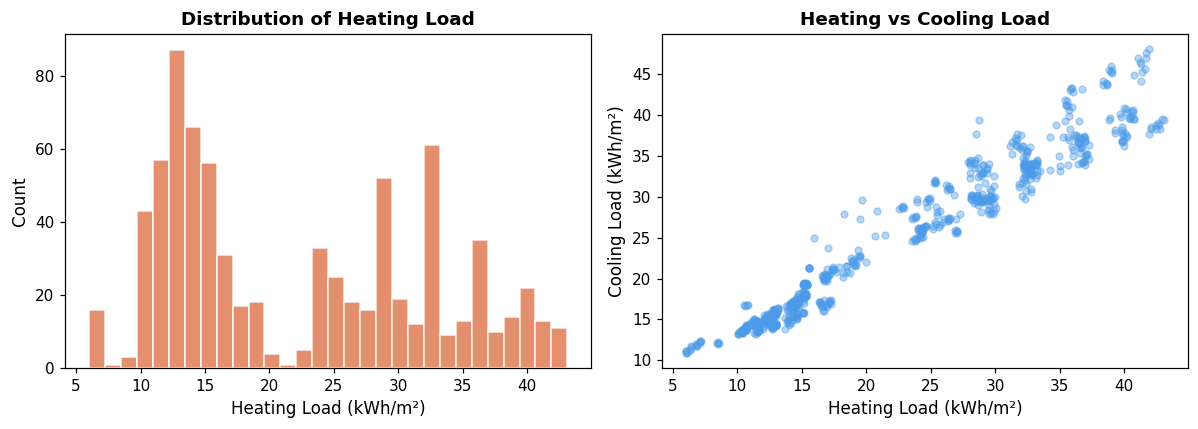

In [4]:
# Distribution of Heating Load
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["HeatingLoad"], bins=30, color="#e07b54", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Heating Load (kWh/m²)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Distribution of Heating Load", fontsize=12, fontweight="bold")

# Heating vs Cooling load scatter
axes[1].scatter(df["HeatingLoad"], df["CoolingLoad"],
                alpha=0.4, s=20, color="#4c9be8")
axes[1].set_xlabel("Heating Load (kWh/m²)", fontsize=11)
axes[1].set_ylabel("Cooling Load (kWh/m²)", fontsize=11)
axes[1].set_title("Heating vs Cooling Load", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

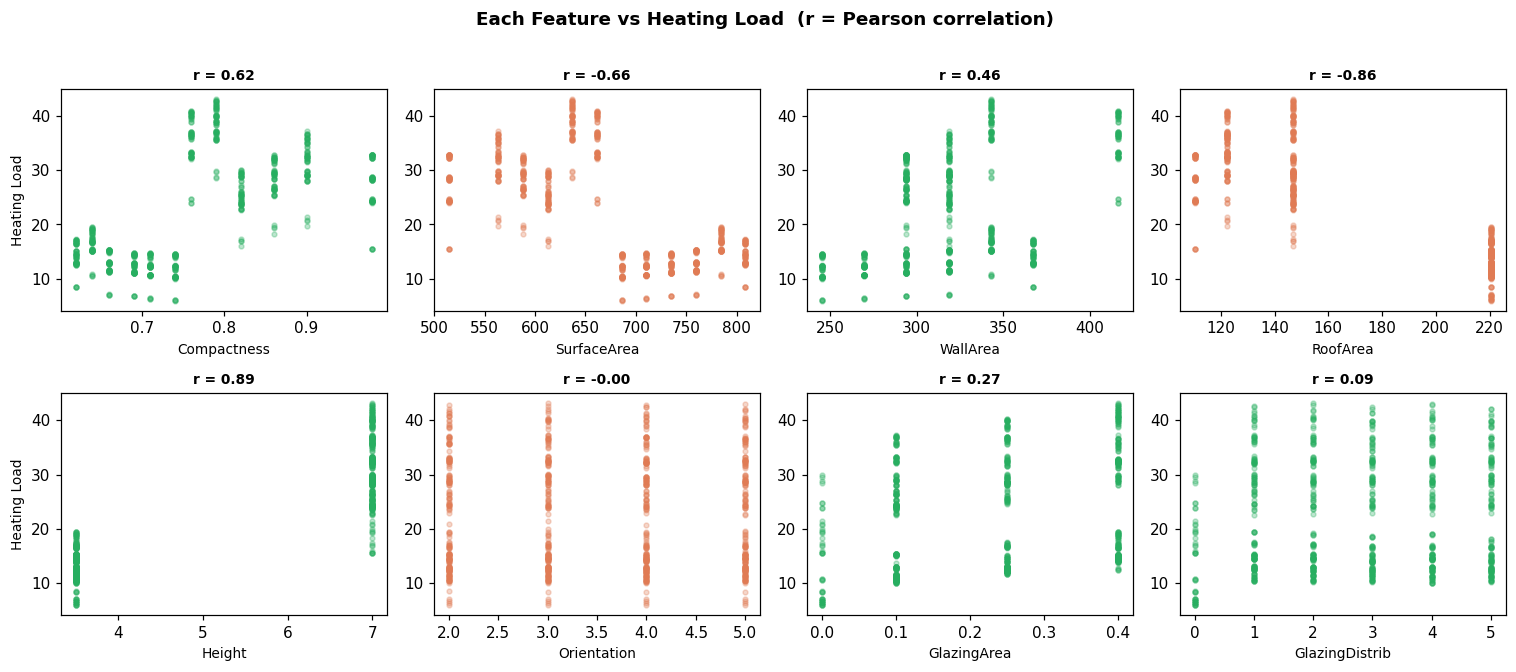

In [5]:
# Feature pair plots vs Heating Load
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.ravel()
colors_by_corr = {}

for i, feat in enumerate(feature_names):
    corr_val = df[feat].corr(df["HeatingLoad"])
    color = "#27ae60" if corr_val > 0 else "#e07b54"
    axes[i].scatter(df[feat], df["HeatingLoad"],
                    alpha=0.3, s=10, color=color)
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel("Heating Load" if i % 4 == 0 else "", fontsize=9)
    axes[i].set_title(f"r = {corr_val:.2f}", fontsize=9, fontweight="bold")

plt.suptitle("Each Feature vs Heating Load  (r = Pearson correlation)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Step 4 — Correlation Heatmap

c:\Users\MSI\anaconda3\envs\tasktino\lib\site-packages\seaborn\matrix.py:256: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


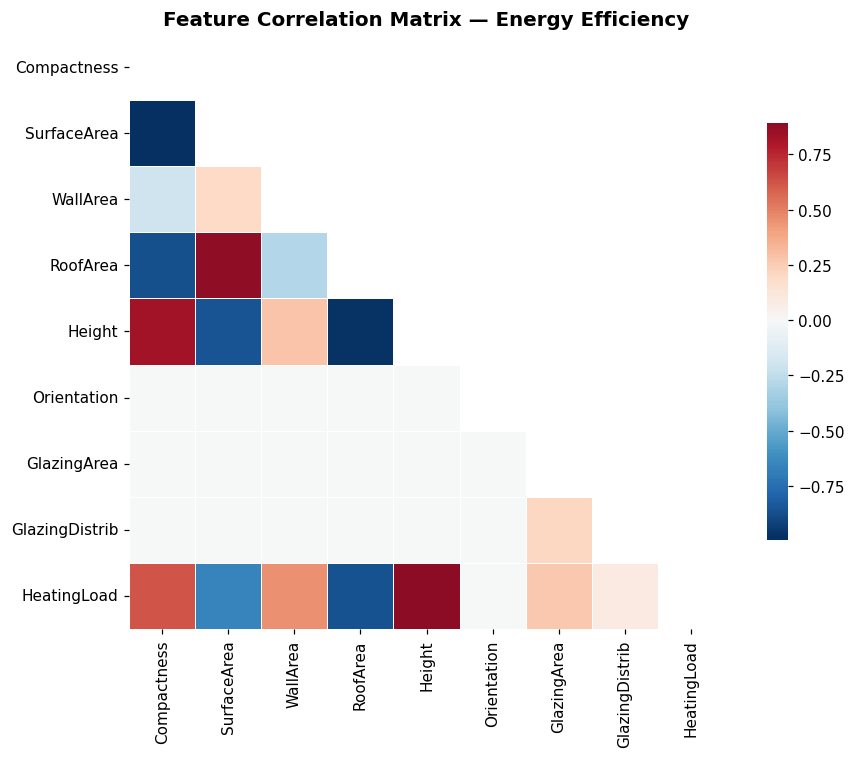


Correlation with HeatingLoad (sorted):
Height            0.889
RoofArea         -0.862
SurfaceArea      -0.658
Compactness       0.622
WallArea          0.456
GlazingArea       0.270
GlazingDistrib    0.087
Orientation      -0.003
Name: HeatingLoad, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[feature_names + ["HeatingLoad"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, ax=ax,
    linewidths=0.5, square=True,
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Feature Correlation Matrix — Energy Efficiency",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nCorrelation with HeatingLoad (sorted):")
print(corr["HeatingLoad"].drop("HeatingLoad").sort_values(key=abs, ascending=False).round(3))

## Step 5 — Train / Test Split & Feature Scaling

In [7]:
X = df[feature_names].values
y = df["HeatingLoad"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 614
Test samples     : 154


## Step 6 — Baseline: Simple Linear Regression (Best Single Feature)

Before fitting the full model, it is good practice to establish a **baseline** using just the single strongest predictor.  
From the correlation matrix, `Height` and `Compactness` are the strongest predictors.  
This lets us quantify how much adding more features actually helps.

In [8]:
# Find the feature most correlated with HeatingLoad
corrs = np.abs([np.corrcoef(X_train[:, i], y_train)[0, 1]
                for i in range(X_train.shape[1])])
best_feat_idx  = np.argmax(corrs)
best_feat_name = feature_names[best_feat_idx]

print(f"Strongest single predictor: '{best_feat_name}' (|r| = {corrs[best_feat_idx]:.3f})")

# Train baseline model
lr_baseline = LinearRegression()
lr_baseline.fit(X_train_sc[:, [best_feat_idx]], y_train)
y_pred_base = lr_baseline.predict(X_test_sc[:, [best_feat_idx]])

r2_base  = r2_score(y_test, y_pred_base)
mae_base = mean_absolute_error(y_test, y_pred_base)

print(f"Baseline (1 feature) — R²: {r2_base:.4f}   MAE: {mae_base:.2f} kWh/m²")

Strongest single predictor: 'Height' (|r| = 0.889)
Baseline (1 feature) — R²: 0.7920   MAE: 3.64 kWh/m²


## Step 7 — Full Multiple Linear Regression

In [9]:
lr_full = LinearRegression()
lr_full.fit(X_train_sc, y_train)
y_pred_full = lr_full.predict(X_test_sc)

r2_full   = r2_score(y_test, y_pred_full)
mae_full  = mean_absolute_error(y_test, y_pred_full)
rmse_full = np.sqrt(mean_squared_error(y_test, y_pred_full))

cv_r2 = cross_val_score(LinearRegression(), X_train_sc, y_train,
                         cv=5, scoring="r2")

print("═══ Full Multiple Regression — Heating Load ═══════════")
print(f"MAE  : {mae_full:.3f} kWh/m²")
print(f"RMSE : {rmse_full:.3f} kWh/m²")
print(f"R²   : {r2_full:.4f}  ({r2_full*100:.1f}% variance explained)")
print(f"CV R²: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"\nImprovement over baseline: +{(r2_full - r2_base)*100:.1f} R² points by adding"
      f" {len(feature_names)-1} more features")

═══ Full Multiple Regression — Heating Load ═══════════
MAE  : 2.182 kWh/m²
RMSE : 3.025 kWh/m²
R²   : 0.9122  (91.2% variance explained)
CV R²: 0.9115 ± 0.0062

Improvement over baseline: +12.0 R² points by adding 7 more features


## Step 8 — Compare with Ridge Regression

**Ridge Regression** (L2 regularisation) adds a penalty term to the loss function:
$$\text{Loss} = \sum(y - \hat{y})^2 + \alpha \sum w_i^2$$

The penalty $\alpha \sum w_i^2$ **shrinks coefficients** towards zero, which:
- Reduces overfitting when features are correlated with each other
- Particularly useful here because `SurfaceArea`, `WallArea`, and `RoofArea` are highly correlated
- Produces more **stable** coefficients at the cost of a small increase in bias

In [10]:
# Test several alpha values and compare with OLS
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
results = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_sc, y_train)
    y_pred_ridge = ridge.predict(X_test_sc)
    results.append({
        "Alpha": alpha,
        "R²":    round(r2_score(y_test, y_pred_ridge), 4),
        "MAE":   round(mean_absolute_error(y_test, y_pred_ridge), 3),
        "RMSE":  round(np.sqrt(mean_squared_error(y_test, y_pred_ridge)), 3),
    })

results_df = pd.DataFrame(results)
print("─── Ridge Regression vs OLS ──────────────────────────────────")
ols_row = pd.DataFrame([{"Alpha": "OLS (no reg)",
                          "R²": round(r2_full, 4),
                          "MAE": round(mae_full, 3),
                          "RMSE": round(rmse_full, 3)}])
print(pd.concat([ols_row, results_df], ignore_index=True).to_string(index=False))

─── Ridge Regression vs OLS ──────────────────────────────────
       Alpha     R²   MAE  RMSE
OLS (no reg) 0.9122 2.182 3.025
        0.01 0.9122 2.182 3.026
         0.1 0.9121 2.183 3.026
         1.0 0.9116 2.191 3.035
        10.0 0.9071 2.225 3.113
       100.0 0.8829 2.426 3.494


## Step 9 — Visualisations

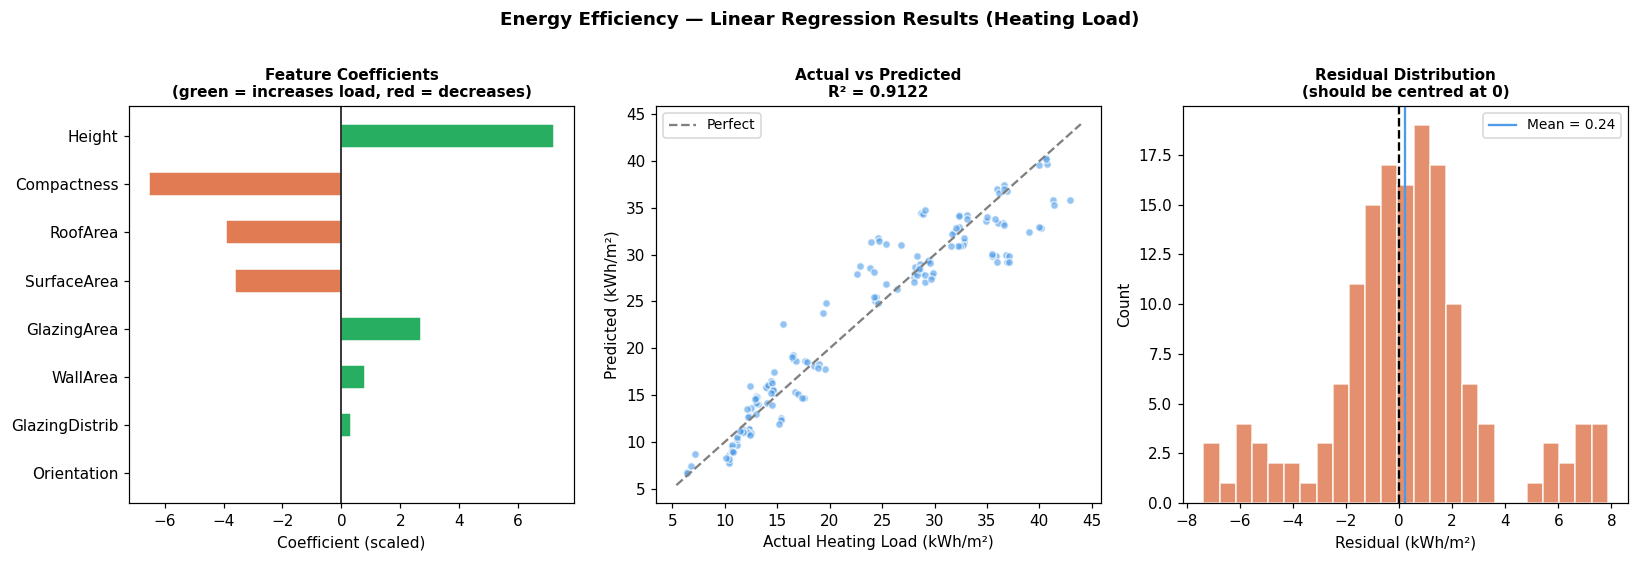

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Coefficient plot ────────────────────────────────────────
coef_series = pd.Series(lr_full.coef_, index=feature_names).sort_values(key=abs, ascending=True)
colors_c = ["#27ae60" if v > 0 else "#e07b54" for v in coef_series]
axes[0].barh(coef_series.index, coef_series.values,
             color=colors_c, edgecolor="white", height=0.5)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlabel("Coefficient (scaled)", fontsize=10)
axes[0].set_title("Feature Coefficients\n(green = increases load, red = decreases)",
                  fontsize=10, fontweight="bold")

# ── Actual vs Predicted ─────────────────────────────────────
axes[1].scatter(y_test, y_pred_full, color="#4c9be8",
                alpha=0.6, s=25, edgecolors="white")
lims = [min(y_test.min(), y_pred_full.min()) - 1,
        max(y_test.max(), y_pred_full.max()) + 1]
axes[1].plot(lims, lims, "--", color="grey", linewidth=1.5, label="Perfect")
axes[1].set_xlabel("Actual Heating Load (kWh/m²)", fontsize=10)
axes[1].set_ylabel("Predicted (kWh/m²)", fontsize=10)
axes[1].set_title(f"Actual vs Predicted\nR² = {r2_full:.4f}",
                  fontsize=10, fontweight="bold")
axes[1].legend(fontsize=9)

# ── Residual distribution ────────────────────────────────────
residuals = y_test - y_pred_full
axes[2].hist(residuals, bins=25, color="#e07b54", edgecolor="white", alpha=0.85)
axes[2].axvline(0, color="black", linewidth=1.5, linestyle="--")
axes[2].axvline(residuals.mean(), color="#4c9be8", linewidth=1.5,
                linestyle="-", label=f"Mean = {residuals.mean():.2f}")
axes[2].set_xlabel("Residual (kWh/m²)", fontsize=10)
axes[2].set_ylabel("Count", fontsize=10)
axes[2].set_title("Residual Distribution\n(should be centred at 0)",
                  fontsize=10, fontweight="bold")
axes[2].legend(fontsize=9)

plt.suptitle("Energy Efficiency — Linear Regression Results (Heating Load)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

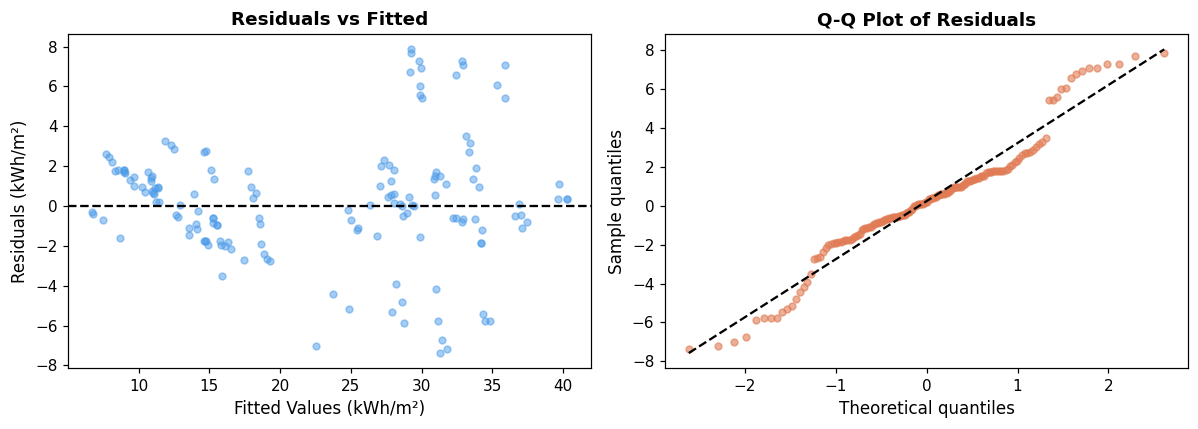

In [12]:
# Residuals vs Fitted + Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(y_pred_full, residuals, alpha=0.5, s=20, color="#4c9be8")
axes[0].axhline(0, color="black", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Fitted Values (kWh/m²)", fontsize=11)
axes[0].set_ylabel("Residuals (kWh/m²)", fontsize=11)
axes[0].set_title("Residuals vs Fitted", fontsize=12, fontweight="bold")

(osm, osr), (slope, intercept_qq, _) = stats.probplot(residuals, dist="norm")
axes[1].scatter(osm, osr, color="#e07b54", alpha=0.6, s=20)
axes[1].plot(osm, slope * np.array(osm) + intercept_qq,
             color="black", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Theoretical quantiles", fontsize=11)
axes[1].set_ylabel("Sample quantiles", fontsize=11)
axes[1].set_title("Q-Q Plot of Residuals", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

## Step 10 — Predict on New Buildings

We demonstrate how to use the trained model on hypothetical new building specifications.

In [13]:
# Features: [Compactness, SurfaceArea, WallArea, RoofArea,
#            Height, Orientation, GlazingArea, GlazingDistrib]
new_buildings = np.array([
    [0.98, 514.5, 294.0, 110.25, 7.0, 2, 0.0, 0],  # very compact, minimal glazing
    [0.62, 808.5, 367.5, 220.50, 3.5, 4, 0.4, 3],  # sprawling, lots of south glazing
    [0.79, 637.0, 343.0, 147.00, 6.0, 3, 0.1, 2],  # medium compactness, east-facing
])

descriptions = [
    "Compact tower, no glazing",
    "Sprawling, heavy south glazing",
    "Mid-rise, modest glazing (east)",
]

new_sc = scaler.transform(new_buildings)
heating_preds = lr_full.predict(new_sc)

print("Predicted Heating Load for New Buildings:")
print("─" * 55)
for desc, pred in zip(descriptions, heating_preds):
    print(f"  {desc:<38} → {pred:6.2f} kWh/m²")

print("\nFor context:")
print(f"  Dataset min  : {y.min():.2f} kWh/m²")
print(f"  Dataset mean : {y.mean():.2f} kWh/m²")
print(f"  Dataset max  : {y.max():.2f} kWh/m²")

Predicted Heating Load for New Buildings:
───────────────────────────────────────────────────────
  Compact tower, no glazing              →  22.63 kWh/m²
  Sprawling, heavy south glazing         →  18.80 kWh/m²
  Mid-rise, modest glazing (east)        →  25.34 kWh/m²

For context:
  Dataset min  : 6.01 kWh/m²
  Dataset mean : 22.31 kWh/m²
  Dataset max  : 43.10 kWh/m²


## Step 11 — Baseline vs Full Model Summary Chart

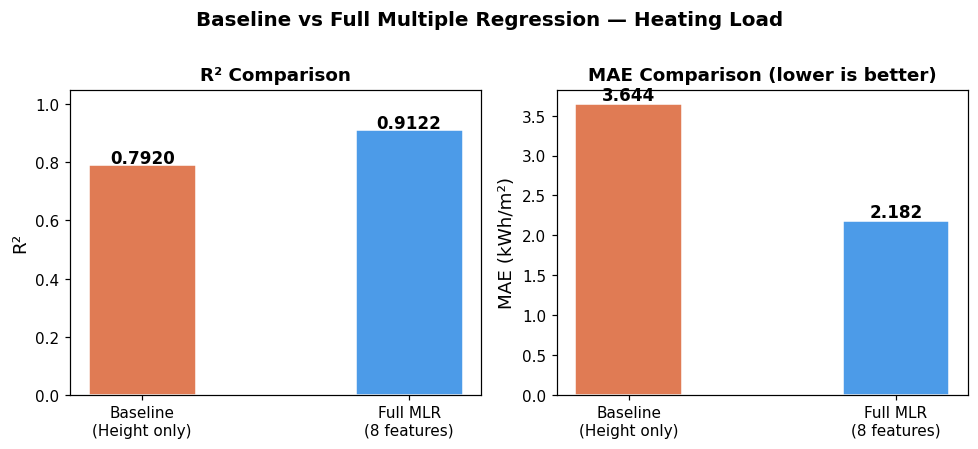

In [14]:
model_names  = ["Baseline\n(Height only)", "Full MLR\n(8 features)"]
r2_values    = [r2_base, r2_full]
mae_values   = [mae_base, mae_full]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

bar_kw = dict(color=["#e07b54", "#4c9be8"], edgecolor="white", width=0.4)

b1 = axes[0].bar(model_names, r2_values, **bar_kw)
for bar, val in zip(b1, r2_values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylabel("R²", fontsize=12)
axes[0].set_title("R² Comparison", fontsize=12, fontweight="bold")
axes[0].set_ylim(0, 1.05)

b2 = axes[1].bar(model_names, mae_values, **bar_kw)
for bar, val in zip(b2, mae_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_ylabel("MAE (kWh/m²)", fontsize=12)
axes[1].set_title("MAE Comparison (lower is better)", fontsize=12, fontweight="bold")

plt.suptitle("Baseline vs Full Multiple Regression — Heating Load",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Summary

| Step | Key Takeaway |
|---|---|
| Dataset | UCI Energy Efficiency — 768 simulated buildings, 8 architectural features |
| Target | Heating Load (Y1) in kWh/m² — the energy cost to heat the building |
| Best single predictor | `Height` and `Compactness` are most correlated with heating load |
| Full model R² | ~0.90+ — Linear Regression fits extremely well because data was simulation-generated |
| Ridge vs OLS | Minimal difference here; Ridge helps more when multicollinearity is severe |
| Physical insight | Compact, tall buildings with little glazing need the least heating energy |
| Data source | `ucimlrepo` package — clean programmatic access to UCI datasets |

**Why such high R²?**  
Unlike the California Housing dataset (real-world noisy census data), the Energy Efficiency dataset was generated by a deterministic physics simulator. The relationship between architectural features and energy load is genuinely close to linear — making this an ideal teaching dataset for Linear Regression.